# Classification Models

## 1. Import Packages

In [1]:
!pip install 'numpy<2.3' --break-system-packages

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib as mpl


# importing metrics
from custom_functions import plot_conf_mat
from custom_functions import plot_roc_curve
from custom_functions import plot_feature_importance
from custom_functions import calculateMetricsAndPrint
from sklearn.metrics import log_loss

import shap

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import sklearn # The machine learning library we will be using in this entire course
from sklearn.linear_model import LogisticRegression
from sklearn import tree # Tree function is used for visualizing decision tree
from sklearn.metrics import * # Importing function that can be used to calculate different metrics
from sklearn.tree import DecisionTreeClassifier # Importing Decision Tree Classifier 
from sklearn.ensemble import RandomForestClassifier  # Importing Random Forest Classifier 
from sklearn.model_selection import train_test_split # Importing function that can split a dataset into training and testing set
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # Importing function for scaling the data
from sklearn.preprocessing import LabelEncoder # Importing function for processing the labels
from sklearn.ensemble import GradientBoostingClassifier # Importing GB Classifier
from sklearn.model_selection import GridSearchCV # Importing GridSearchCV
from sklearn.model_selection import RandomizedSearchCV # Importing RandomSearchCV
from xgboost import XGBClassifier # Importing the XGBoost Classifier 
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe


  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.21.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.2.0 which is incompatib

In [2]:
def summarize_dataframe(df):
    """Summarize a dataframe, and report missing values."""
    missing_values = pd.concat([pd.DataFrame(df.columns, columns=['Variable Name']), 
                      pd.DataFrame(df.dtypes.values.reshape([-1,1]), columns=['Data Type']),
                      pd.DataFrame(df.isnull().sum().values, columns=['Missing Values']), 
                      pd.DataFrame([df[name].nunique() for name in df.columns], columns=['Unique Values'])], 
                     axis=1).set_index('Variable Name')
    with pd.option_context("display.max_rows", 1000):
        display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))

## 2. Read and View the Data

In [ ]:
data = pd.read_csv('03_Analysis/clean_data_7-9-26_9-47-PM.csv.gz')

In [4]:
summarize_dataframe(data)

/tmp/ipykernel_80/168232490.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  display(pd.concat([missing_values, df.describe(include='all').transpose()], axis=1).fillna(""))


,Data Type,Missing Values,Unique Values,count,unique,top,freq,mean,std,min,25%,50%,75%,max
acn,int64,0,33723,33723.0,,,,1828811.478783,192110.173434,1507557.0,1673862.5,1806271.0,1981117.5,2296796.0
event_date,object,0,84,33723.0,84,2019-11-01,622,,,,,,,
narrative_text,object,0,33715,33723.0,33715,The UAS lost the telemetry link 1;300 feet fro...,3,,,,,,,
synopsis,object,1,33668,33722.0,33668,Part 107 UAS pilot reported flying in controll...,9,,,,,,,
word_count,int64,0,1306,33723.0,,,,261.27207,216.912553,2.0,119.0,205.0,334.0,2345.0
hedge_score,float64,0,2537,33723.0,,,,0.002822,0.004726,0.0,0.0,0.0,0.004545,0.142857
passive_voice_ratio,float64,0,632,33723.0,,,,0.183942,0.170208,0.0,0.0588,0.15,0.2667,1.0
causal_connective_count,int64,0,17,33723.0,,,,0.704801,1.17733,0.0,0.0,0.0,1.0,20.0
specificity_score,float64,0,5,33723.0,,,,0.27244,0.223232,0.0,0.0,0.25,0.5,1.0
named_entity_count,int64,0,113,33723.0,,,,13.275094,11.897187,0.0,5.0,10.0,18.0,144.0


In [5]:
# Convert to actual datetime dtype
data['event_date'] = pd.to_datetime(data['event_date'])

# Confirm the conversion worked
print(data['event_date'].dtype)  # should now show datetime64[ns]

datetime64[ns]


In [6]:
# Have to filter out any ZZZ due to compromise of recurrence definition and shuffling with random seed 1, also drop days to recurrence since this is logistic regression, also remove events occurring before 12-31-2023 to remove right censored data
filtered_data = data[(data['airport'] != 'ZZZ') & (data['event_date']<'2023-12-31')].drop(columns = ['days_to_recurrence', 'is_right_censored']).dropna(subset=['self_score', 'actual_severity', 'potential_severity'])

df = filtered_data[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity',
           'recurrence_flag',
           ]].sample(frac=1,random_state=1) # Shuffles the data with a random seed of 1
    

summarize_dataframe(df)

,Data Type,Missing Values,Unique Values,count,mean,std,min,25%,50%,75%,max
hedge_score,float64,0,1320,9625.0,0.002938,0.004819,0.0000,0.0000,0.0000,0.004785,0.047619
passive_voice_ratio,float64,0,332,9625.0,0.179287,0.160124,0.0000,0.0588,0.1538,0.258100,1.000000
causal_connective_count,int64,0,14,9625.0,0.696727,1.157206,0.0000,0.0000,0.0000,1.000000,14.000000
specificity_score,float64,0,5,9625.0,0.302182,0.225580,0.0000,0.2500,0.2500,0.500000,1.000000
type_token_ratio,float64,0,3346,9625.0,0.541652,0.128530,0.2203,0.4514,0.5241,0.614800,1.000000
self_score,float64,0,2,9625.0,0.198130,0.398611,0.0000,0.0000,0.0000,0.000000,1.000000
actual_severity,float64,0,5,9625.0,1.420156,0.553355,1.0000,1.0000,1.0000,2.000000,5.000000
potential_severity,float64,0,5,9625.0,3.517610,0.937870,1.0000,3.0000,4.0000,4.000000,5.000000
recurrence_flag,int64,0,2,9625.0,0.064416,0.245505,0.0000,0.0000,0.0000,0.000000,1.000000


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data: first carve out test set, then split remainder into train/validation
X = df.drop(columns=['recurrence_flag'])
y = df.recurrence_flag

# Step 1: separate out the final test set (held out entirely until final reporting)
X_temp, testData, y_temp, testLabels = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

# Step 2: split the remainder into train and validation
trainData, valData, trainLabels, valLabels = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=1, stratify=y_temp
)

# Scaling continuous cols after splitting - leaving out self score (binary categorical) and the potential and actual severity scores (ordinals)
continuous_cols = [
    'causal_connective_count',
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',
]

std_scaler = StandardScaler()

# Fit ONLY on training data
scaled_trainData = trainData.copy()
scaled_trainData[continuous_cols] = std_scaler.fit_transform(trainData[continuous_cols])

# Transform validation and test using the SAME fitted scaler — never fit_transform on these
scaled_valData = valData.copy()
scaled_valData[continuous_cols] = std_scaler.transform(valData[continuous_cols])

scaled_testData = testData.copy()
scaled_testData[continuous_cols] = std_scaler.transform(testData[continuous_cols])

In [8]:
# Check the balance of the target variable
recurrence = df.recurrence_flag.value_counts()
print('Class Counts')
print(recurrence)
print('=========')
print('Recurrence Rate')
print(recurrence[1] / recurrence[0])

Class Counts
recurrence_flag
0    9005
1     620
Name: count, dtype: int64
Recurrence Rate
0.06885063853414769


## 3. Analyses without Control Variables

### 3.1 Logistic Regression

In [9]:
# Statsmodel version for summary, unweighted, unregularized

# Add an X constant
X_with_constant = sm.add_constant(scaled_trainData)
Xtest_with_constant = sm.add_constant(scaled_testData)

sm_logistic = sm.Logit(trainLabels, X_with_constant).fit()
sm_logistic.summary()

Optimization terminated successfully.
         Current function value: 0.236796
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        recurrence_flag   No. Observations:                 6160
Model:                          Logit   Df Residuals:                     6151
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                0.009367
Time:                        21:48:23   Log-Likelihood:                -1458.7
converged:                       True   LL-Null:                       -1472.5
Covariance Type:            nonrobust   LLR p-value:                 0.0005597
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -2.4055      0.227    -10.594      0.000      -2.851      -1.960
hedge_score                -0.0841      0.055     -1.525      0.127      -0.192       0.024
passive_voice_ratio        -0.0189      0.052     -0.364      0.716      -0.120       0.083
causal_connective_count    -0.0281      0.062     -0.451      0.652      -0.150       0.094
specificity_score          -0.1089      0.058     -1.893      0.058      -0.222       0.004
type_token_ratio            0.0770      0.059      1.307      0.191      -0.038       0.192
self_score                 -0.3275      0.154     -2.124      0.034      -0.630      -0.025
actual_severity            -0.2008      0.102     -1.968      0.049      -0.401      -0.001
potential_severity          0.0132      0.058      0.229      0.819      -0.100       0.126
===========================================================================================
"""

In [99]:
sm_logistic_pred_proba_1d = sm_logistic.predict(Xtest_with_constant)  # 1D, P(class=1) only

# Reconstruct the 2-column format calculateMetricsAndPrint expects
sm_logistic_pred_proba = np.column_stack([1 - sm_logistic_pred_proba_1d, sm_logistic_pred_proba_1d])

threshold = 0.08
sm_logistic_pred = (sm_logistic_pred_proba_1d >= threshold).astype(int)

calculateMetricsAndPrint(sm_logistic_pred, sm_logistic_pred_proba, testLabels)

Accuracy: 78.86
PrecisionNegative: 93.78
PrecisionPositive: 7.51
RecallNegative: 82.90
RecallPositive: 20.16
AUC Score: 54.94



In [11]:
# Scikit version for displaying performance, L2 regularization, class weights applied, threshold at default 0.5
# Training the model
logistic = LogisticRegression(random_state = 1,class_weight = 'balanced', max_iter=1000).fit(scaled_trainData, trainLabels)

logistic_pred = logistic.predict(scaled_testData)
logistic_pred_proba = logistic.predict_proba(scaled_testData)

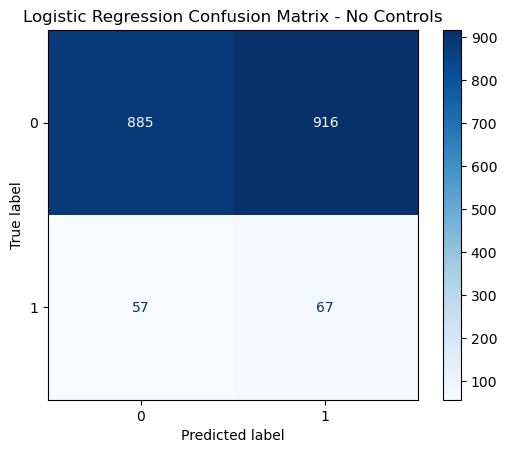

In [12]:
# Plot the Confusion Matrix

plot_conf_mat(logistic, # The classifier object
              testData, # The test data set aside for evaluation in train_test_split
              testLabels, # Actual labels
              title = 'Logistic Regression Confusion Matrix - No Controls'
             )

In [13]:
calculateMetricsAndPrint(logistic_pred, logistic_pred_proba, testLabels)

Accuracy: 53.04
PrecisionNegative: 94.36
PrecisionPositive: 7.33
RecallNegative: 52.97
RecallPositive: 54.03
AUC Score: 55.20



AUC Score = 55.197


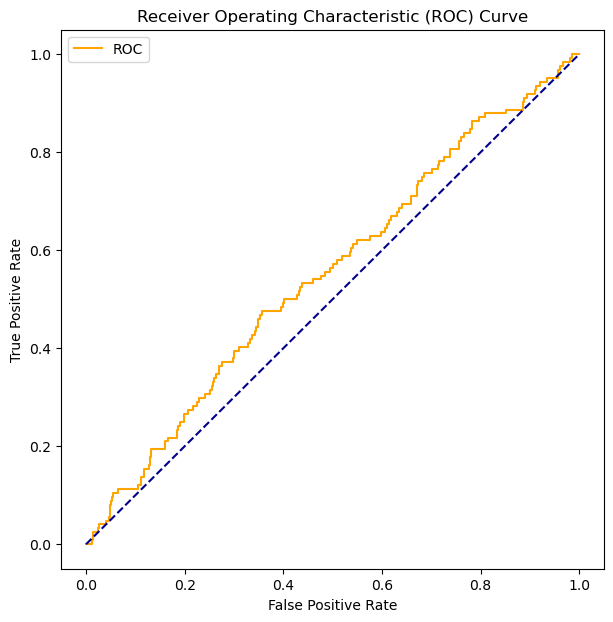

In [14]:
plot_roc_curve(testLabels, logistic_pred_proba[:,1])

### 3.2 Hyper Opted XGB Model

In [15]:
space={'max_depth': hp.quniform("max_depth", 1, 10, 1),
       'n_estimators': hp.quniform('n_estimators', 40, 200, 10),
       'learning_rate': hp.uniform ('learning_rate', 0.05,0.3),
       'subsample': hp.uniform ('subsample', 0.5,1.0),
       'colsample_bytree': hp.uniform ('colsample_bytree', 0.5,1.0),
       'min_child_weight': hp.uniform ('min_child_weight', 1,10),
       'gamma': hp.uniform ('gamma', 0,5),
       'random_state': 1
    }

def objective(space):
    hclf=XGBClassifier(
        random_state = 1,
        learning_rate = space['learning_rate'],
        n_estimators = int(space['n_estimators']), 
        max_depth = int(space['max_depth']), 
        subsample = space['subsample'],
        colsample_bytree = space['colsample_bytree'],
        min_child_weight = space['min_child_weight'],
        gamma = space['gamma'],
        early_stopping_rounds=10,
        eval_metric="auc")
    
    evaluation = [( scaled_trainData, trainLabels), (scaled_valData, valLabels)]
    
    hclf.fit(scaled_trainData, trainLabels,
            eval_set=evaluation, verbose=False)
    
    hpred = hclf.predict_proba(scaled_testData)[:,1]
    accuracy = log_loss(testLabels, hpred)

    print ("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK }

In [16]:
%%capture --no-display

trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

In [17]:
print("The best hyperparameters are : ","\n")
print(best_hyperparams)

The best hyperparameters are :  

{'colsample_bytree': np.float64(0.7344117189941191), 'gamma': np.float64(0.5864104828068981), 'learning_rate': np.float64(0.116892397289245), 'max_depth': np.float64(7.0), 'min_child_weight': np.float64(7.671078570540864), 'n_estimators': np.float64(120.0), 'subsample': np.float64(0.6384883438379588)}


In [18]:
best_hyperparams_hypopt = {'colsample_bytree': np.float64(0.5505251208059088),
                           'gamma': np.float64(2.835538699356367),
                           'learning_rate': np.float64(0.05548571899478798),
                           'max_depth': np.int64(10.0),
                           'min_child_weight': np.float64(1.619199778714388),
                           'n_estimators': np.int64(150.0),
                           'subsample': np.float64(0.9500423320229091)
                          }

final_model = XGBClassifier(**best_hyperparams_hypopt, random_state=1)

In [19]:
# Combine train and val data for final model
final_trainData = pd.concat([scaled_trainData, scaled_valData], axis=0)
final_trainLabels = pd.concat([trainLabels, valLabels], axis=0)

# Train final model on combined train data
final_model.fit(final_trainData,final_trainLabels)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.5505251208059088)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [20]:
# Define a custom confusion matrix function that allows me to customize my own threshold for the model below
def cust_plot_conf_mat(y_test, y_pred, title='Confusion matrix for our classifier'):
    matrix = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

In [91]:
predictedProbabilities = final_model.predict_proba(scaled_testData)  # full 2-column array
custom_preds = (predictedProbabilities[:, 1] >= 0.0065).astype(int) 

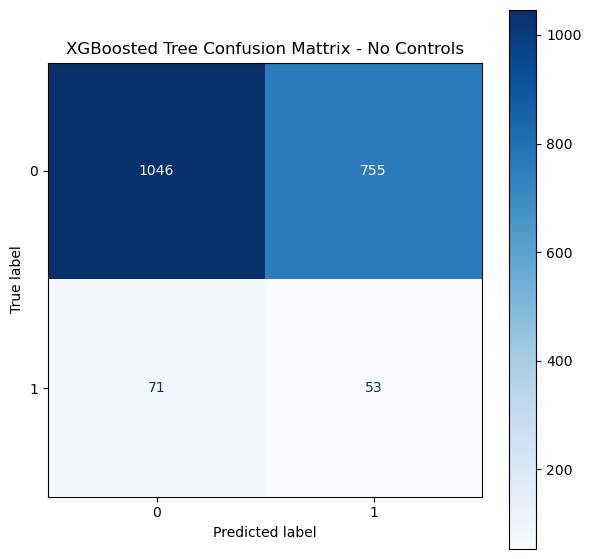

In [92]:
cust_plot_conf_mat(testLabels, custom_preds, title = 'XGBoosted Tree Confusion Mattrix - No Controls')

In [93]:
calculateMetricsAndPrint(custom_preds, predictedProbabilities, testLabels)

Accuracy: 57.09
PrecisionNegative: 93.64
PrecisionPositive: 6.56
RecallNegative: 58.08
RecallPositive: 42.74
AUC Score: 54.37



In [94]:
print("F1 Score:",f1_score(testLabels, custom_preds, average='micro'))

F1 Score: 0.5709090909090909


AUC Score = 54.369


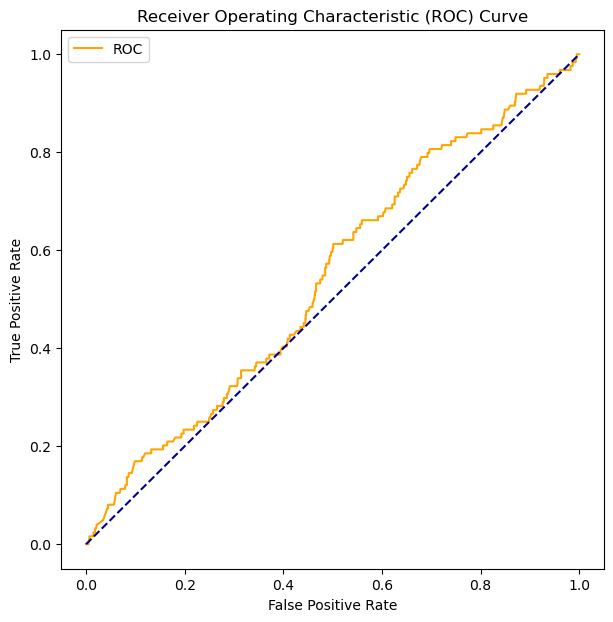

In [25]:
positiveProbabilities = predictedProbabilities[:,1]
plot_roc_curve(testLabels, # Actual labels
               positiveProbabilities, # Prediction scores for the positive class
               pos_label = 1 # Indicate the label that corresponds to the positive class
              )

In [26]:
print("Log-Loss Score:",log_loss(testLabels, positiveProbabilities)) 

Log-Loss Score: 0.23885727132080503


In [27]:
probs = final_model.predict_proba(scaled_testData)[:, 1]
print(pd.Series(probs).describe())  # or pd.Series(probs).describe()
print(probs.max())  # is the highest predicted probability even close to 0.5?

count    1925.000000
mean        0.064287
std         0.018343
min         0.032035
25%         0.051347
50%         0.061472
75%         0.073931
max         0.156077
dtype: float64
0.1560769


In [28]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(testLabels, probs)

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (max F1): {best_threshold:.4f}")
print(f"Precision at this threshold: {precision[best_idx]:.3f}")
print(f"Recall at this threshold: {recall[best_idx]:.3f}")

Best threshold (max F1): 0.0611
Precision at this threshold: 0.078
Recall at this threshold: 0.613


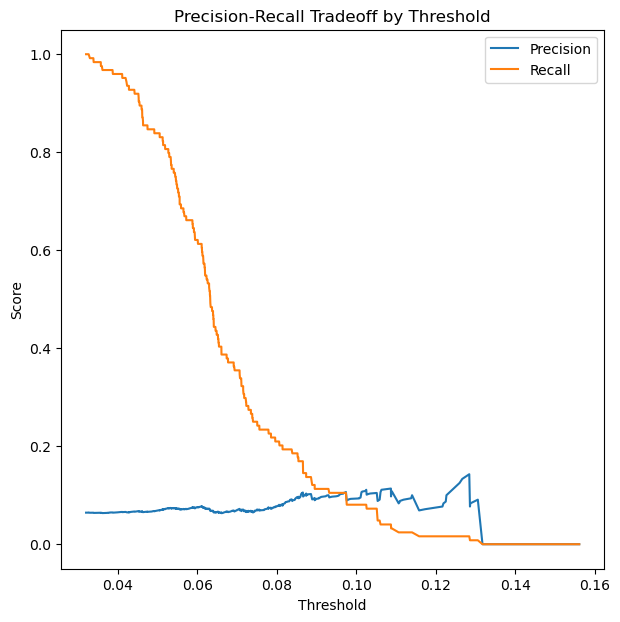

In [29]:
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall Tradeoff by Threshold')
plt.show()

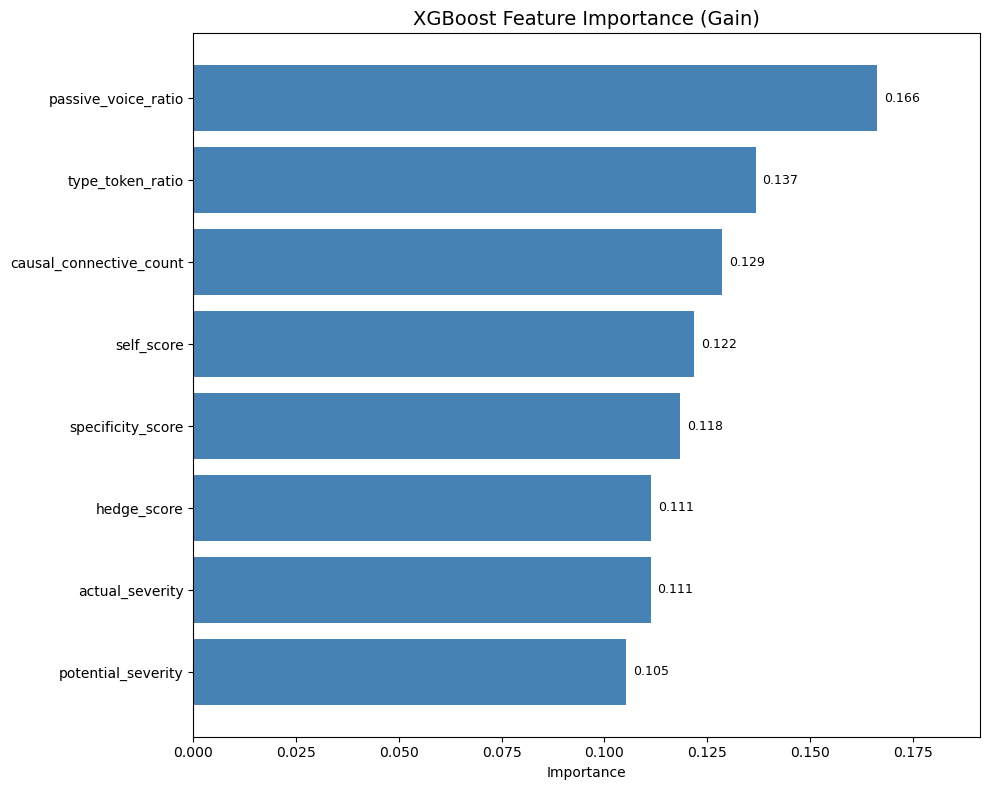

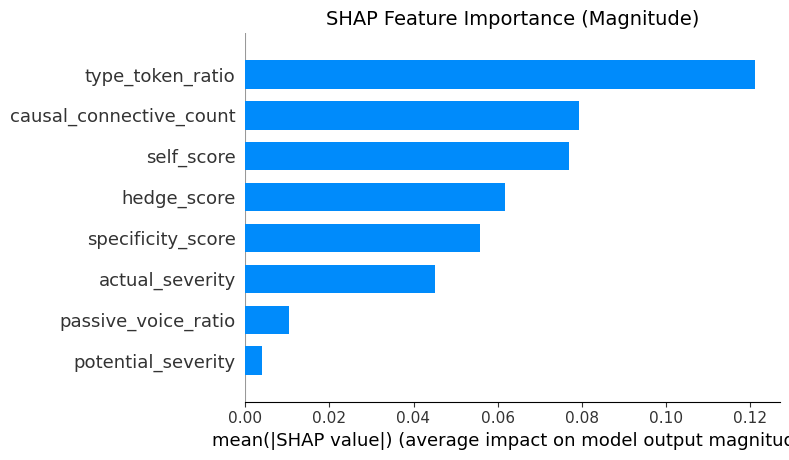

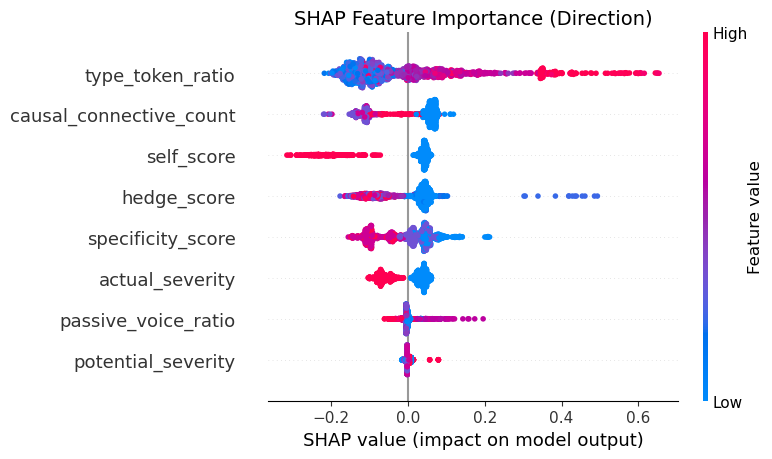

In [30]:
# --- Gain-based feature importance ---
importances = final_model.feature_importances_
imp_series = pd.Series(importances, index=scaled_trainData.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp_series.index, imp_series.values, color='steelblue')
ax.set_title('XGBoost Feature Importance (Gain)', fontsize=14)
ax.set_xlabel('Importance')

for bar, val in zip(bars, imp_series.values):
    ax.text(bar.get_width() + (imp_series.max() * 0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, imp_series.max() * 1.15)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP values ---
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(scaled_testData)

# Magnitude (bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, scaled_testData, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Magnitude)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()

# Direction (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, scaled_testData, show=False)
plt.title('SHAP Feature Importance (Direction)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_direction.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Running the Analysis Again Using all Control Variables

### 4.1 Additional Data Cleaning

In [31]:
# Create a list of all categorical columns - need to use their dummy coded columns instead
drop_columns = [
    'acn',
    'word_count',
    'named_entity_count',
    'event_date',
    'narrative_text',
    'synopsis',
    'label_method',
    'anomaly_code',
    'location_id',
    'airport',
    'organizational_unit',
    'country',
    'state',
    'city',
    'airport_type',
    'aircraft_type',
    'reporter_function',
    'flight_phase',
    'FlightConditions',
    'Light',
    'Mission',
    'PrimaryProblem',
    'days_to_recurrence',
    'is_right_censored',
    'airport_ZZZ',
    'anomaly_GroundEvent/EncounterLossOfVLOS(UAS)',
    'anomaly_InflightEvent/EncounterFlyAway(UAS)',
    'airport_type_heliport',
    'phase_Downwind',
    'phase_ReturntoHome(UAS)',
    'phase_flightseveraldays'
]

# removing: word_count, named_entity_count, due to collinearity issues identified in correlation matrix
# removing the following due to very low frequency: airport_ZZZ 'anomaly_GroundEvent/EncounterLossOfVLOS(UAS)', 'anomaly_InflightEvent/EncounterFlyAway(UAS)',
# 'airport_type_heliport', 'phase_Downwind', 'phase_ReturntoHome(UAS)', 'phase_flightseveraldays'

# Have to filter out any ZZZ due to compromise of recurrence definition and shuffling with random seed 1
filtered_full_data = data[(data['airport'] != 'ZZZ') & (data['event_date']<'2023-12-31')].drop(columns = drop_columns).dropna(subset=['self_score', 'actual_severity', 'potential_severity', 'CrewSize'])

full_df = filtered_full_data.sample(frac=1,random_state=1)

summarize_dataframe(full_df)

,Data Type,Missing Values,Unique Values,count,mean,std,min,25%,50%,75%,max
hedge_score,float64,0,1262,8777.0,0.002918,0.004763,0.0000,0.0000,0.0000,0.004739,0.044444
passive_voice_ratio,float64,0,323,8777.0,0.180134,0.160868,0.0000,0.0588,0.1538,0.260900,1.000000
causal_connective_count,int64,0,14,8777.0,0.695682,1.158584,0.0000,0.0000,0.0000,1.000000,14.000000
specificity_score,float64,0,5,8777.0,0.302638,0.225353,0.0000,0.2500,0.2500,0.500000,1.000000
type_token_ratio,float64,0,3251,8777.0,0.541842,0.128417,0.2203,0.4521,0.5238,0.614500,1.000000
recurrence_flag,int64,0,2,8777.0,0.064373,0.245430,0.0000,0.0000,0.0000,0.000000,1.000000
self_score,float64,0,2,8777.0,0.200980,0.400756,0.0000,0.0000,0.0000,0.000000,1.000000
actual_severity,float64,0,5,8777.0,1.423379,0.555974,1.0000,1.0000,1.0000,2.000000,5.000000
potential_severity,float64,0,5,8777.0,3.516463,0.936076,1.0000,3.0000,4.0000,4.000000,5.000000
anomaly_ATCIssueAllTypes,int64,0,2,8777.0,0.354107,0.478269,0.0000,0.0000,0.0000,1.000000,1.000000


In [32]:
len(full_df.columns)

358

In [33]:
full_df.recurrence_flag.value_counts()

recurrence_flag
0    8212
1     565
Name: count, dtype: int64

In [34]:

# Split the data: first carve out test set, then split remainder into train/validation
full_X = full_df.drop(columns=['recurrence_flag'])
full_y = full_df.recurrence_flag

# Step 1: separate out the final test set (held out entirely until final reporting)
full_X_temp, full_testData, full_y_temp, full_testLabels = train_test_split(
    full_X, full_y, test_size=0.2, random_state=1, stratify=full_y
)

# Step 2: split the remainder into train and validation
full_trainData, full_valData, full_trainLabels, full_valLabels = train_test_split(
    full_X_temp, full_y_temp, test_size=0.2, random_state=1, stratify=full_y_temp
)

# Scaling continuous cols after splitting - leaving out self score (binary categorical) and the potential and actual severity scores (ordinals)
continuous_cols = [
    'causal_connective_count', 'CrewSize',
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',
]

std_scaler = StandardScaler()

# Fit ONLY on training data
full_scaled_trainData = full_trainData.copy()
full_scaled_trainData[continuous_cols] = std_scaler.fit_transform(full_trainData[continuous_cols])

# Transform validation and test using the SAME fitted scaler
full_scaled_valData = full_valData.copy()
full_scaled_valData[continuous_cols] = std_scaler.transform(full_valData[continuous_cols])

full_scaled_testData = full_testData.copy()
full_scaled_testData[continuous_cols] = std_scaler.transform(full_testData[continuous_cols])

### 4.2 Logistic Regression Using All Features

In [35]:
# Statsmodel version for summary, unweighted, had to add regularization (default is l1 'lasso') just to run so many variables - otherwise no convergence

# Add an X constant
full_X_with_constant = sm.add_constant(full_scaled_trainData)
full_Xtest_with_constant = sm.add_constant(full_scaled_testData)

full_sm_logistic = sm.Logit(full_trainLabels, full_X_with_constant).fit_regularized(alpha=1.0)
full_sm_logistic.summary()

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.19260293705446715
            Iterations: 754
            Function evaluations: 755
            Gradient evaluations: 754


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        recurrence_flag   No. Observations:                 5616
Model:                          Logit   Df Residuals:                     5434
Method:                           MLE   Df Model:                          181
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.2595
Time:                        21:52:24   Log-Likelihood:                -994.20
converged:                       True   LL-Null:                       -1342.6
Covariance Type:            nonrobust   LLR p-value:                 1.411e-61
=============================================================================================================================================
                                                                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------
const                                                                        -0.4291   3.42e+05  -1.25e-06      1.000   -6.71e+05    6.71e+05
hedge_score                                                                  -0.0272      0.060     -0.452      0.652      -0.145       0.091
passive_voice_ratio                                                           0.0190      0.059      0.319      0.750      -0.098       0.136
causal_connective_count                                                       0.0125      0.071      0.175      0.861      -0.127       0.152
specificity_score                                                            -0.0694      0.067     -1.043      0.297      -0.200       0.061
type_token_ratio                                                              0.0847      0.072      1.180      0.238      -0.056       0.225
self_score                                                                   -0.1454      0.180     -0.807      0.420      -0.499       0.208
actual_severity                                                              -0.1334      0.124     -1.072      0.284      -0.377       0.111
potential_severity                                                           -0.0580      0.091     -0.636      0.525      -0.237       0.121
anomaly_ATCIssueAllTypes                                                     -0.0637      0.159     -0.400      0.689      -0.375       0.248
anomaly_AircraftEquipmentProblemCritical                                     -1.5578      0.627     -2.486      0.013      -2.786      -0.330
anomaly_AircraftEquipmentProblemLessSevere                                   -0.7728      0.230     -3.365      0.001      -1.223      -0.323
anomaly_AirspaceViolationAllTypes                                            -0.6270      0.351     -1.787      0.074      -1.315       0.061
anomaly_ConflictAirborneConflict                                             -0.2631      0.220     -1.197      0.231      -0.694       0.168
anomaly_ConflictGroundConflict                                               -0.9304      0.343     -2.712      0.007      -1.603      -0.258
anomaly_ConflictNMAC                                                         -0.0340      0.248     -0.137      0.891      -0.521       0.453
anomaly_Critical                                                                   0        nan        nan        nan         nan         nan
anomaly_Deviation-AltitudeCrossingRestrictionNotMet                          -0.7442      0.572     -1.302      0.193      -1.864       0.376
anomaly_Deviation-AltitudeExcursionFromAssignedAltitude                      -0.9462      0.353     -2.681      0.007      -1.638      -0.254
anomaly_Deviation-AltitudeOvershoot                                          -0.9828      0.460     -2.137      0.033

In [85]:
# Calculate Predictive Performance Metrics for the Statsmodel 
full_sm_logistic_pred_proba_1d = full_sm_logistic.predict(full_Xtest_with_constant)  # 1D, P(class=1) only

# Reconstruct the 2-column format calculateMetricsAndPrint expects
full_sm_logistic_pred_proba = np.column_stack([1 - full_sm_logistic_pred_proba_1d, full_sm_logistic_pred_proba_1d])

threshold = 0.065
full_sm_logistic_pred = (full_sm_logistic_pred_proba_1d >= threshold).astype(int)

calculateMetricsAndPrint(full_sm_logistic_pred, full_sm_logistic_pred_proba, full_testLabels)

Accuracy: 70.44
PrecisionNegative: 98.12
PrecisionPositive: 15.48
RecallNegative: 69.75
RecallPositive: 80.53
AUC Score: 82.57



In [87]:
# Training the scikit learn model
full_logistic = LogisticRegression(random_state = 1,class_weight = 'balanced', max_iter=1000).fit(full_scaled_trainData, full_trainLabels)

full_logistic_pred = full_logistic.predict(full_scaled_testData)
full_logistic_pred_proba = full_logistic.predict_proba(full_scaled_testData)

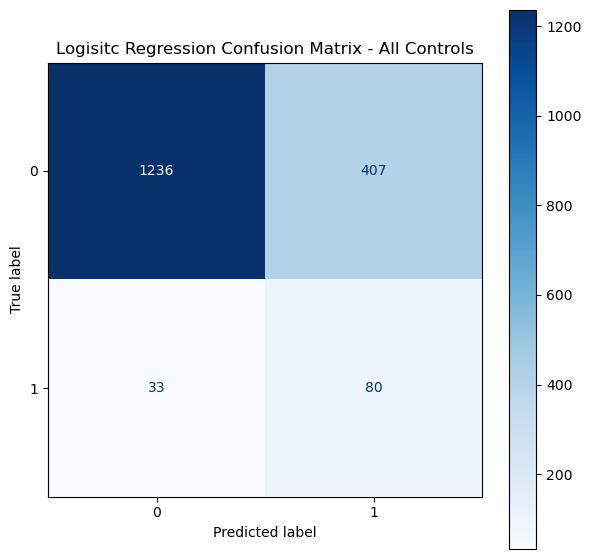

In [88]:
# Plot the Confusion Matrix

plot_conf_mat(full_logistic, # The classifier object
              full_scaled_testData, # The test data set aside for evaluation in train_test_split
              full_testLabels, # Actual labels
              title = 'Logisitc Regression Confusion Matrix - All Controls'
             )

In [89]:
calculateMetricsAndPrint(full_logistic_pred, full_logistic_pred_proba, full_testLabels)

Accuracy: 74.94
PrecisionNegative: 97.40
PrecisionPositive: 16.43
RecallNegative: 75.23
RecallPositive: 70.80
AUC Score: 81.11



AUC Score = 81.111


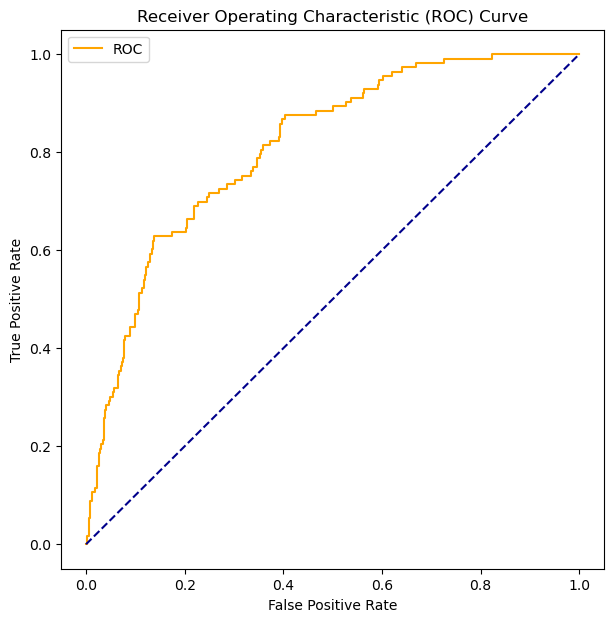

In [90]:
plot_roc_curve(full_testLabels, full_logistic_pred_proba[:,1])

### 4.3 Hyper Opted XGB Model Using All Features

In [50]:
space={'max_depth': hp.quniform("max_depth", 1, 10, 1),
       'n_estimators': hp.quniform('n_estimators', 40, 200, 10),
       'learning_rate': hp.uniform ('learning_rate', 0.05,0.3),
       'subsample': hp.uniform ('subsample', 0.1,1.0),
       'colsample_bytree': hp.uniform ('colsample_bytree', 0.1,1.0),
       'min_child_weight': hp.uniform ('min_child_weight', 1,10),
       'gamma': hp.uniform ('gamma', 0,5),
       'random_state': 1
    }

def objective(space):
    full_hclf=XGBClassifier(
        random_state = 1,
        learning_rate = space['learning_rate'],
        n_estimators = int(space['n_estimators']), 
        max_depth = int(space['max_depth']), 
        subsample = space['subsample'],
        colsample_bytree = space['colsample_bytree'],
        min_child_weight = space['min_child_weight'],
        gamma = space['gamma'],
        early_stopping_rounds=10,
        eval_metric="auc")
    
    evaluation = [( full_scaled_trainData, full_trainLabels), (full_scaled_valData, full_valLabels)]
    
    full_hclf.fit(full_scaled_trainData, full_trainLabels,
            eval_set=evaluation, verbose=False)
    
    full_hpred = full_hclf.predict_proba(full_scaled_testData)[:,1]
    accuracy = log_loss(full_testLabels, full_hpred)

    print ("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK }

In [51]:
%%capture --no-display

trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

In [52]:
print("The best hyperparameters are : ","\n")
print(best_hyperparams)

The best hyperparameters are :  

{'colsample_bytree': np.float64(0.10917223608331245), 'gamma': np.float64(0.49054218146394224), 'learning_rate': np.float64(0.07294789535505715), 'max_depth': np.float64(7.0), 'min_child_weight': np.float64(5.019298821033095), 'n_estimators': np.float64(100.0), 'subsample': np.float64(0.5694274000149389)}


In [53]:
full_best_hyperparams_hypopt = {'colsample_bytree': np.float64(0.5505251208059088),
                           'gamma': np.float64(2.835538699356367),
                           'learning_rate': np.float64(0.05548571899478798),
                           'max_depth': np.int64(10.0),
                           'min_child_weight': np.float64(1.619199778714388),
                           'n_estimators': np.int64(150.0),
                           'subsample': np.float64(0.9500423320229091)
                          }

full_final_model = XGBClassifier(**full_best_hyperparams_hypopt, randomstate=1)

In [54]:
# Combine train and val sets for final fit
full_final_trainData = pd.concat([full_scaled_trainData, full_scaled_valData], axis=0)
full_final_trainLabels = pd.concat([full_trainLabels, full_valLabels], axis=0)

# Train final model on combined train data
full_final_model.fit(full_final_trainData,full_final_trainLabels)

/opt/conda/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [21:53:10] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/learner.cc:740: 
Parameters: { "randomstate" } are not used.

  warnings.warn(smsg, UserWarning)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.5505251208059088)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [55]:
full_predictedProbabilities = full_final_model.predict_proba(full_scaled_testData)  # full 2-column array
full_custom_preds = (full_predictedProbabilities[:, 1] >= 0.08).astype(int) 

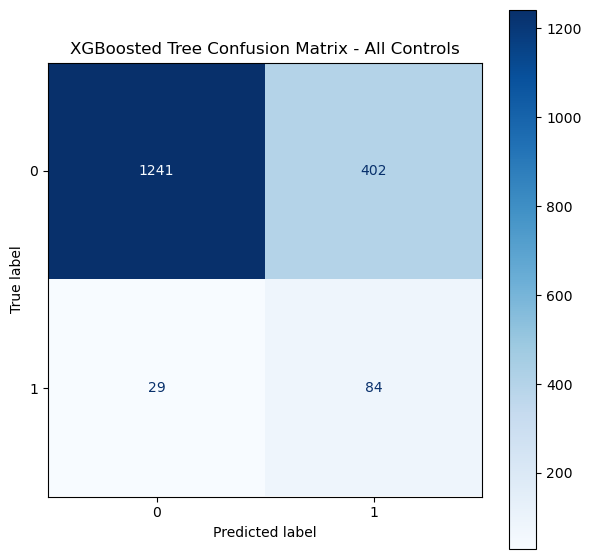

In [56]:
cust_plot_conf_mat(full_testLabels, full_custom_preds, title = 'XGBoosted Tree Confusion Matrix - All Controls' )

In [57]:
calculateMetricsAndPrint(full_custom_preds, full_predictedProbabilities, full_testLabels)

Accuracy: 75.46
PrecisionNegative: 97.72
PrecisionPositive: 17.28
RecallNegative: 75.53
RecallPositive: 74.34
AUC Score: 82.53



In [58]:
print("F1 Score:",f1_score(full_testLabels, full_custom_preds, average='micro'))

F1 Score: 0.7545558086560364


AUC Score = 82.529


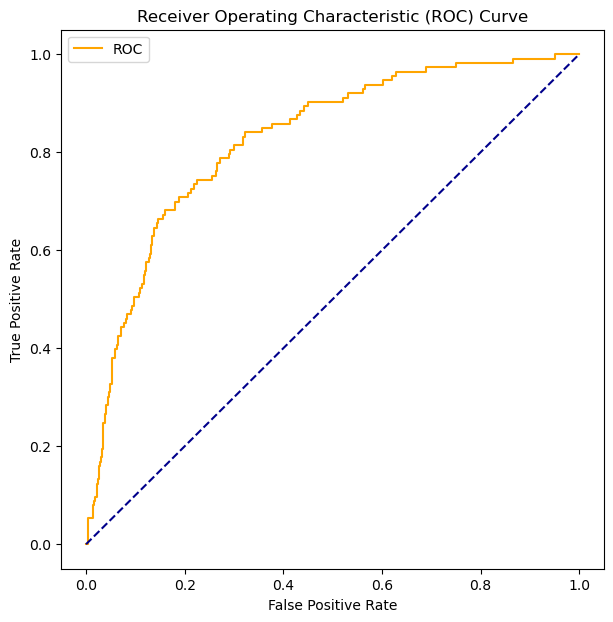

In [59]:
full_positiveProbabilities = full_predictedProbabilities[:,1]
plot_roc_curve(full_testLabels, # Actual labels
               full_positiveProbabilities, # Prediction scores for the positive class
               pos_label = 1 # Indicate the label that corresponds to the positive class
              )

In [60]:
print("Log-Loss Score:",log_loss(full_testLabels, full_positiveProbabilities)) 

Log-Loss Score: 0.19636353199965687


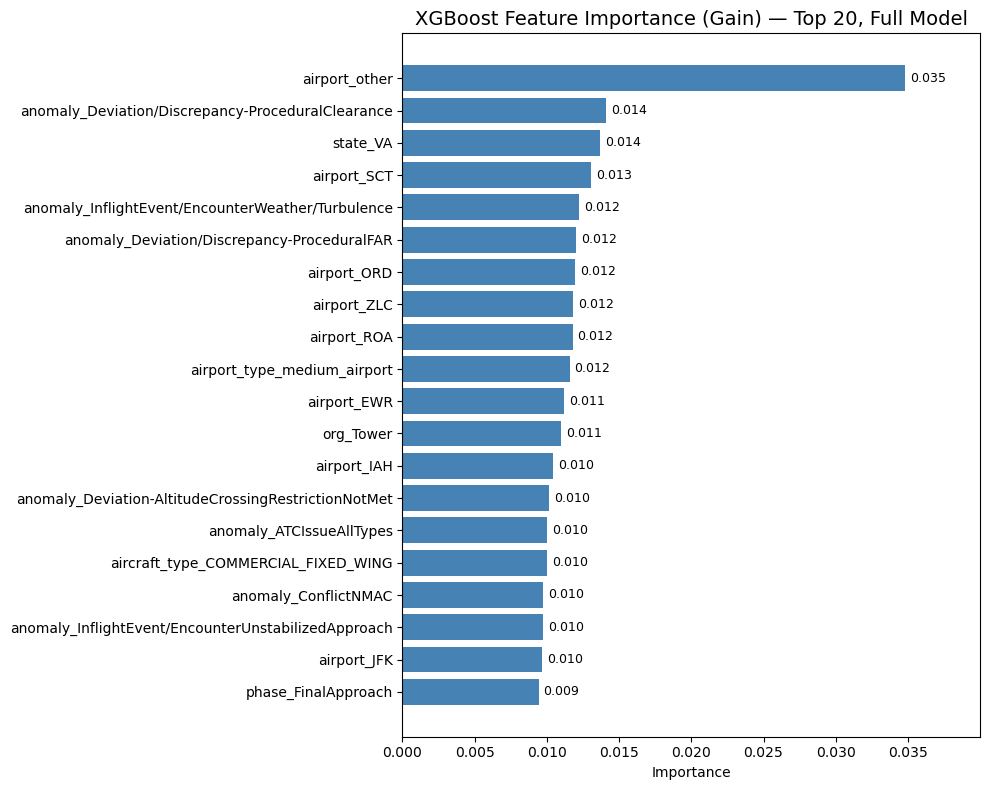

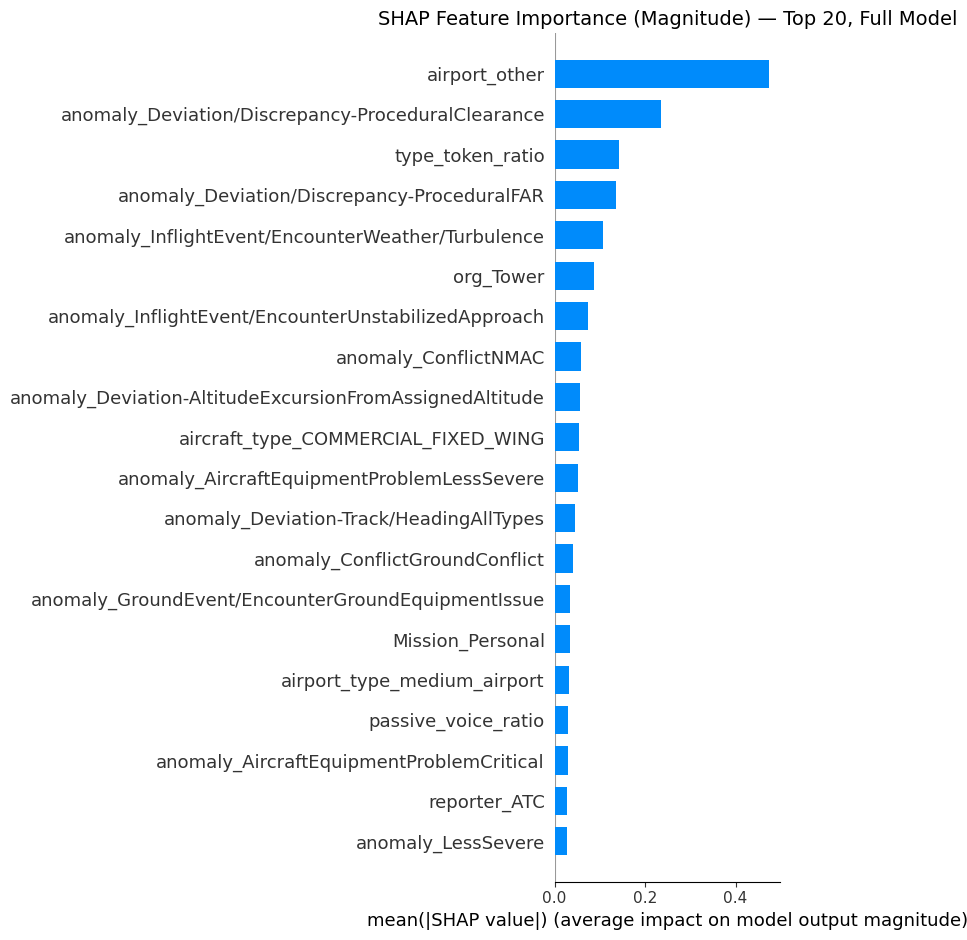

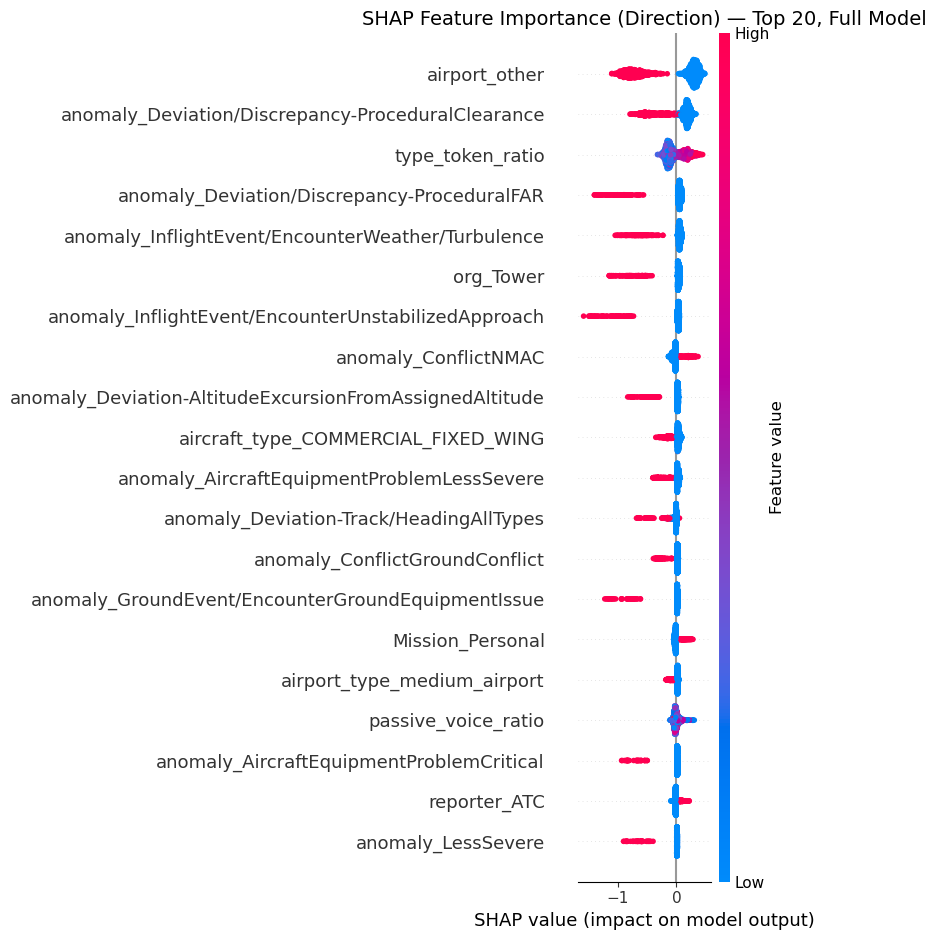

In [61]:
# --- Gain-based feature importance (top 20) ---
top_n = 20
importances = full_final_model.feature_importances_
imp_series = pd.Series(importances, index=full_final_trainData.columns).sort_values(ascending=True)
imp_series_top = imp_series.tail(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp_series_top.index, imp_series_top.values, color='steelblue')
ax.set_title(f'XGBoost Feature Importance (Gain) — Top {top_n}, Full Model', fontsize=14)
ax.set_xlabel('Importance')

for bar, val in zip(bars, imp_series_top.values):
    ax.text(bar.get_width() + (imp_series_top.max() * 0.01), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
ax.set_xlim(0, imp_series_top.max() * 1.15)

plt.tight_layout()
plt.savefig('full_feature_importance_top20.png', dpi=150, bbox_inches='tight')
plt.show()

# --- SHAP values (top 20) ---
explainer = shap.TreeExplainer(full_final_model)
shap_values = explainer.shap_values(full_scaled_testData)

# Magnitude (bar)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, full_scaled_testData, plot_type="bar", max_display=top_n, show=False)
plt.title(f'SHAP Feature Importance (Magnitude) — Top {top_n}, Full Model', fontsize=14)
plt.tight_layout()
plt.savefig('full_shap_magnitude_top20.png', dpi=150, bbox_inches='tight')
plt.show()

# Direction (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, full_scaled_testData, max_display=top_n, show=False)
plt.title(f'SHAP Feature Importance (Direction) — Top {top_n}, Full Model', fontsize=14)
plt.tight_layout()
plt.savefig('full_shap_direction_top20.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Logistic Regressions Again - Using Interaction Terms

These logistic regressions will again focus primarily on the linguistic and severity scores. However, this time, they will each be interacted with the airport variable and then again with the airport and organizational_unit variables in a second analysis.

The value of this is that for each linguistic feature and severity score, the model will calculate a unique regression slope for each airport (for the first regression) and each unique combination of airport and organizational_unit (for the second regression). This means we can see how these dynamics play out differently at each organization/team (wehther we define that at the aiport level, or the sub-airport/organizational_unit level). Otherwise, the logistic regressions before this only calculated regression slopes as an aggregate of the whole data set - which drowned out the unique effects at individual organizations. Our hypothesis is that these effects are stronger at problematic organizations and weaker at non-problematic organizations - so teasing out individual effects is important.

### 5.1 Grouping by Airports

In [62]:
# Compare rates of recurrence across airports

airport_recurrence_rate = (
    data.groupby('airport')['recurrence_flag']
    .agg(recurrence_rate='mean', recurrence_count='sum', total_count='count')
    .reset_index()
    .sort_values('recurrence_count', ascending=False)
)
with pd.option_context("display.max_rows", 100):
    display(airport_recurrence_rate)

,airport,recurrence_rate,recurrence_count,total_count
89,ZZZ,0.343271,7749,22574
90,other,0.025165,118,4689
19,DEN,0.161172,44,273
46,ORD,0.169355,42,248
35,LAX,0.164948,32,194
23,EWR,0.129310,30,232
59,SCT,0.123529,21,170
62,SFO,0.102273,18,176
54,ROA,0.272727,18,66
80,ZLC,0.188889,17,90


In [63]:
# Finding only airports that have 10 or more recurrences

high_rates = airport_recurrence_rate[(airport_recurrence_rate['recurrence_count']>=10) & (airport_recurrence_rate['airport']!= 'ZZZ') & (airport_recurrence_rate['airport']!= 'other')]
print(high_rates)

   airport  recurrence_rate  recurrence_count  total_count
19     DEN         0.161172                44          273
46     ORD         0.169355                42          248
35     LAX         0.164948                32          194
23     EWR         0.129310                30          232
59     SCT         0.123529                21          170
62     SFO         0.102273                18          176
54     ROA         0.272727                18           66
80     ZLC         0.188889                17           90
72     ZDC         0.170213                16           94
30     IAH         0.111888                16          143
36     LGA         0.096296                13          135
69     ZAB         0.115044                13          113
77     ZJX         0.122449                12           98
9      BOS         0.123596                11           89
3      ATL         0.096491                11          114
61     SEA         0.118280                11           

In [64]:
# Making a list of those airports with recurrences >= 10
recurring_airports = high_rates['airport'].to_list()
print(recurring_airports)
print(len(recurring_airports))

['DEN', 'ORD', 'LAX', 'EWR', 'SCT', 'SFO', 'ROA', 'ZLC', 'ZDC', 'IAH', 'LGA', 'ZAB', 'ZJX', 'BOS', 'ATL', 'SEA', 'N90', 'NCT']
18


In [65]:
# Grouping by airports 


ap_data = filtered_data[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity',
           'recurrence_flag',
           'airport',               # Have to add these to back in for this next model
           'organizational_unit'    # Have to add these to back in for this next model
           ]].sample(frac=1,random_state=1) # Shuffles the data with a random seed of 1


r_data = ap_data[ap_data['airport'].isin(recurring_airports)]

# Scaling continuous cols to fit models on full data - leaving out self score (binary categorical) and the potential and acutal severity scores (ordinals)
continuous_cols = [
    'causal_connective_count',  # counts
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',  # ratios
]



# Splitting unscaled data to prepare for predictive modeling
r_X = r_data.drop(columns = ['recurrence_flag'])
r_y = r_data.recurrence_flag

recurring_train, recurring_test, recurring_trainLabels, recurring_testLabels = train_test_split(
    r_X, r_y, test_size=0.2, random_state=1, stratify=r_y
)


# Scaling the data and then scaling train and test data post-split

std_scaler = StandardScaler()

recurring_data = r_data.copy()
recurring_data[continuous_cols] = std_scaler.fit_transform(r_data[continuous_cols])

scaled_recurring_train = recurring_train.copy()
scaled_recurring_test = recurring_test.copy()

scaled_recurring_train[continuous_cols] = std_scaler.fit_transform(recurring_train[continuous_cols])
scaled_recurring_test[continuous_cols] = std_scaler.transform(recurring_test[continuous_cols])


In [66]:
# Fit a linear regression with interaction terms for airport


recurring_smf_model = smf.logit("recurrence_flag ~ hedge_score:C(airport) + passive_voice_ratio:C(airport) + causal_connective_count:C(airport) + specificity_score:C(airport) + type_token_ratio:C(airport) + self_score + actual_severity:C(airport) + potential_severity:C(airport) ", data = recurring_data).fit_regularized(alpha=1.0, maxiter=1000)

print(recurring_smf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3807980542794481
            Iterations: 294
            Function evaluations: 295
            Gradient evaluations: 294
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                 2222
Model:                          Logit   Df Residuals:                     2118
Method:                           MLE   Df Model:                          103
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.09719
Time:                        21:53:17   Log-Likelihood:                -818.77
converged:                       True   LL-Null:                       -906.92
Covariance Type:            nonrobust   LLR p-value:                 9.356e-06
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [67]:
# Test to see how the linear relationship holds at a single airport (EWR) who showed statistical significance

ewr_data = recurring_data[recurring_data['airport']=='EWR']


# Removing interaction terms
recurring_smf_model = smf.logit("recurrence_flag ~ hedge_score + passive_voice_ratio + causal_connective_count + specificity_score + type_token_ratio + self_score + actual_severity + potential_severity", data = ewr_data).fit_regularized(alpha=1.0, maxiter=1000)

print(recurring_smf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.380268532894714
            Iterations: 65
            Function evaluations: 65
            Gradient evaluations: 65
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                  206
Model:                          Logit   Df Residuals:                      197
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.09288
Time:                        21:53:17   Log-Likelihood:                -74.278
converged:                       True   LL-Null:                       -81.883
Covariance Type:            nonrobust   LLR p-value:                   0.05519
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

In [68]:
# Test to see how the linear relationship holds at a single airport (SFO) who showed statistical significance

sfo_data = recurring_data[recurring_data['airport']=='SFO']


# Removing interaction terms
recurring_smf_model = smf.logit("recurrence_flag ~ hedge_score + passive_voice_ratio + causal_connective_count + specificity_score + type_token_ratio + self_score + actual_severity + potential_severity", data = sfo_data).fit_regularized(alpha=1.0, maxiter=1000)

print(recurring_smf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.32856791392852464
            Iterations: 32
            Function evaluations: 32
            Gradient evaluations: 32
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                  149
Model:                          Logit   Df Residuals:                      145
Method:                           MLE   Df Model:                            3
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.09772
Time:                        21:53:17   Log-Likelihood:                -47.725
converged:                       True   LL-Null:                       -52.894
Covariance Type:            nonrobust   LLR p-value:                   0.01591
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

In [69]:
# Test to see if the model generalizes well to new data

# Add an X constant
recurring_X_with_constant = sm.add_constant(scaled_recurring_train)
recurring_Xtest_with_constant = sm.add_constant(scaled_recurring_test)

# Concat train data with train labels

recurring_pred_train = pd.concat([recurring_X_with_constant, recurring_trainLabels], axis=1)

# Train the model
predictive_recurring_smf_model = smf.logit("recurrence_flag ~ hedge_score:C(airport) + passive_voice_ratio:C(airport) + causal_connective_count:C(airport) + specificity_score:C(airport) + type_token_ratio:C(airport) + self_score + actual_severity:C(airport) + potential_severity:C(airport) ", data = recurring_pred_train).fit_regularized(alpha=1.0, maxiter=1000)

print(predictive_recurring_smf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3804463023716458
            Iterations: 330
            Function evaluations: 330
            Gradient evaluations: 330
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                 1777
Model:                          Logit   Df Residuals:                     1684
Method:                           MLE   Df Model:                           92
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.1050
Time:                        21:53:22   Log-Likelihood:                -649.30
converged:                       True   LL-Null:                       -725.44
Covariance Type:            nonrobust   LLR p-value:                 7.905e-05
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

In [95]:
# Calculate Predictive Performance Metrics for the Statsmodel 
recurring_pred_proba_1d = predictive_recurring_smf_model.predict(recurring_Xtest_with_constant)  # 1D, P(class=1) only

# Reconstruct the 2-column format calculateMetricsAndPrint expects
recurring_pred_proba = np.column_stack([1 - recurring_pred_proba_1d, recurring_pred_proba_1d])

threshold = 0.065
recurring_pred = (recurring_pred_proba_1d >= threshold).astype(int)

calculateMetricsAndPrint(recurring_pred, recurring_pred_proba, recurring_testLabels)

Accuracy: 26.74
PrecisionNegative: 88.89
PrecisionPositive: 14.75
RecallNegative: 16.75
RecallPositive: 87.30
AUC Score: 59.35



In [96]:
# Fit a linear regression with interaction terms for airport and organizational unit


recurring_org_smf_model = smf.logit("recurrence_flag ~ hedge_score:C(airport):C(organizational_unit) + passive_voice_ratio:C(airport):C(organizational_unit) + causal_connective_count:C(airport):C(organizational_unit) + specificity_score:C(airport):C(organizational_unit) + type_token_ratio:C(airport):C(organizational_unit) + self_score + actual_severity:C(airport):C(organizational_unit) + potential_severity:C(airport):C(organizational_unit) ", data = recurring_data).fit_regularized(alpha=1.0, maxiter=1000)

print(recurring_org_smf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.37378538218335294
            Iterations: 336
            Function evaluations: 336
            Gradient evaluations: 336
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                 2222
Model:                          Logit   Df Residuals:                     2104
Method:                           MLE   Df Model:                          117
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.1219
Time:                        22:15:34   Log-Likelihood:                -796.34
converged:                       True   LL-Null:                       -906.92
Covariance Type:            nonrobust   LLR p-value:                 2.042e-08
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------

### 5.2 Select for data where the difference between actual_severity and potential_severity is the highest

In [77]:
# Trying with data filtered for specific airports (those with statisitically significant coefficients from above analysis) that show statistical significance in models


rf_filtered_data = data[ (( (data['potential_severity'] - data['actual_severity']) > 2 )  & (data['event_date']<'2023-12-31')  & (data['airport'] != 'ZZZ'))].drop(columns = ['days_to_recurrence', 'is_right_censored']).dropna(subset=['self_score', 'actual_severity', 'potential_severity'])

rf_data = rf_filtered_data[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity',
           'recurrence_flag',
           'airport',
           'organizational_unit'
           ]].sample(frac=1,random_state=1) # Shuffles the data with a random seed of 1

# Split the Data
rf_X = rf_data.drop(columns = ['recurrence_flag'])
rf_y = rf_data.recurrence_flag

rf_trainData, rf_testData, rf_trainLabels, rf_testLabels = train_test_split(
    rf_X, rf_y, test_size=0.2, random_state=1, stratify=rf_y
)


# Scaling continuous cols after splitting - leaving out self score (binary categorical) and the potential and acutal severity scores (ordinals)

continuous_cols = [
    'causal_connective_count',  # counts
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',  # ratios
]

std_scaler = StandardScaler()

scaled_rf_trainData = rf_trainData.copy()
scaled_rf_testData = rf_testData.copy()

scaled_rf_trainData[continuous_cols] = std_scaler.fit_transform(rf_trainData[continuous_cols])
scaled_rf_testData[continuous_cols] = std_scaler.transform(rf_testData[continuous_cols])

In [78]:
# Statsmodel version for summary, unweighted, unregularized

# Add an X constant
rf_X_with_constant = sm.add_constant(scaled_rf_trainData.drop(columns=['airport','organizational_unit']))
rf_Xtest_with_constant = sm.add_constant(scaled_rf_testData.drop(columns=['airport','organizational_unit'])) #Dropping org unit and airport for this test since we don't want to use interaction terms yet

rf_logistic = sm.Logit(rf_trainLabels, rf_X_with_constant).fit()
rf_logistic.summary()

Optimization terminated successfully.
         Current function value: 0.232133
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:        recurrence_flag   No. Observations:                 2340
Model:                          Logit   Df Residuals:                     2331
Method:                           MLE   Df Model:                            8
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                 0.01560
Time:                        22:11:08   Log-Likelihood:                -543.19
converged:                       True   LL-Null:                       -551.80
Covariance Type:            nonrobust   LLR p-value:                   0.02793
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -3.4077      0.777     -4.385      0.000      -4.931      -1.885
hedge_score                -0.0999      0.093     -1.077      0.282      -0.282       0.082
passive_voice_ratio        -0.1258      0.092     -1.371      0.170      -0.306       0.054
causal_connective_count    -0.0179      0.105     -0.171      0.864      -0.223       0.187
specificity_score          -0.1353      0.094     -1.443      0.149      -0.319       0.048
type_token_ratio            0.0475      0.097      0.488      0.626      -0.143       0.239
self_score                 -0.6654      0.313     -2.124      0.034      -1.279      -0.052
actual_severity            -0.2112      0.273     -0.775      0.439      -0.746       0.323
potential_severity          0.2236      0.187      1.198      0.231      -0.142       0.590
===========================================================================================
"""

In [79]:
# Fit a linear regression with interaction terms for airport and org unit - ROA, ORD, LAX, and DEN confirmed worst offenders in both the regression analysis and the means comparison

# Trying with data filtered for specific airports (those with statisitically significant coefficients from above analysis) that show statistical significance in models


rf_filtered_data = data[ (( (data['potential_severity'] - data['actual_severity']) > 2 )  & (data['event_date']<'2023-12-31') & ( (data['airport'] == 'ROA') | (data['airport'] == 'ORD') | (data['airport'] == 'LAX') | (data['airport'] == 'DEN') ))].drop(columns = ['days_to_recurrence', 'is_right_censored']).dropna(subset=['self_score', 'actual_severity', 'potential_severity'])

rf_data = rf_filtered_data[[
           'hedge_score',
           'passive_voice_ratio',
           'causal_connective_count',
           'specificity_score',
           'type_token_ratio',
           'self_score',
           'actual_severity',
           'potential_severity',
           'recurrence_flag',
           'airport',
           'organizational_unit'
           ]].sample(frac=1,random_state=1) # Shuffles the data with a random seed of 1

continuous_cols = [
    'causal_connective_count',  # counts
    'hedge_score', 'passive_voice_ratio', 'specificity_score', 'type_token_ratio',  # ratios
]

scaled_rf_data = rf_data.copy()
scaled_rf_data[continuous_cols] = std_scaler.fit_transform(rf_data[continuous_cols])

rf_model = smf.logit("recurrence_flag ~ hedge_score:C(airport):C(organizational_unit) + passive_voice_ratio:C(airport):C(organizational_unit) + causal_connective_count:C(airport):C(organizational_unit) + specificity_score:C(airport):C(organizational_unit) + type_token_ratio:C(airport):C(organizational_unit) + self_score + actual_severity:C(airport):C(organizational_unit) + potential_severity:C(airport):C(organizational_unit) + hedge_score:C(airport) + passive_voice_ratio:C(airport) + causal_connective_count:C(airport) + specificity_score:C(airport) + type_token_ratio:C(airport) + self_score + actual_severity:C(airport) + potential_severity:C(airport)", 
                     data = scaled_rf_data).fit_regularized(alpha=1.0, maxiter=1000)

print(rf_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.39431001730076626
            Iterations: 105
            Function evaluations: 105
            Gradient evaluations: 105
                           Logit Regression Results                           
Dep. Variable:        recurrence_flag   No. Observations:                  128
Model:                          Logit   Df Residuals:                      108
Method:                           MLE   Df Model:                           19
Date:                Thu, 23 Jul 2026   Pseudo R-squ.:                  0.2801
Time:                        22:11:09   Log-Likelihood:                -43.395
converged:                       True   LL-Null:                       -60.278
Covariance Type:            nonrobust   LLR p-value:                   0.01958
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
-------------

In [80]:
from statsmodels.stats.proportion import proportion_confint

for airport, rate, n in [('ROA', 0.2727, 66), ('ORD', 0.1694, 248), ('LAX', 0.1649, 194), ('DEN', 0.1612, 273)]:
    successes = round(rate * n)
    ci_low, ci_high = proportion_confint(successes, n, alpha=0.05, method='wilson')
    print(f"{airport}: {rate:.3f} (95% CI: {ci_low:.3f} - {ci_high:.3f}), n={n}")

ROA: 0.273 (95% CI: 0.180 - 0.390), n=66
ORD: 0.169 (95% CI: 0.128 - 0.221), n=248
LAX: 0.165 (95% CI: 0.119 - 0.224), n=194
DEN: 0.161 (95% CI: 0.122 - 0.209), n=273


In [81]:
mixed_model = smf.mixedlm(
    "recurrence_flag ~ hedge_score + passive_voice_ratio + specificity_score",
    data=filtered_data,
    groups=filtered_data["airport"],
    re_formula="~hedge_score"  # allows hedge_score's slope to vary randomly by airport
).fit()

/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [82]:
print(mixed_model.summary())
print(mixed_model.cov_re)  # the random effects covariance matrix itself

              Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  recurrence_flag
No. Observations:    9625     Method:              REML           
No. Groups:          90       Scale:               0.0578         
Min. group size:     23       Log-Likelihood:      4.0236         
Max. group size:     3896     Converged:           Yes            
Mean group size:     106.9                                        
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                0.091    0.009 10.616 0.000  0.074  0.108
hedge_score             -0.504    1.274 -0.396 0.692 -3.001  1.992
passive_voice_ratio     -0.001    0.015 -0.046 0.963 -0.031  0.030
specificity_score       -0.038    0.011 -3.464 0.001 -0.059 -0.016
Group Var                0.002    0.003                           
Group x he

In [83]:
random_effects = mixed_model.random_effects  # dict of {airport: [intercept_deviation, slope_deviation]}

import pandas as pd
re_df = pd.DataFrame({airport: vals for airport, vals in random_effects.items()}).T
re_df.columns = ['intercept_deviation', 'hedge_score_slope_deviation']
re_df['total_hedge_score_slope'] = mixed_model.fe_params['hedge_score'] + re_df['hedge_score_slope_deviation']

print(re_df.sort_values('total_hedge_score_slope').head(10))  # airports with strongest negative effect
print(re_df.sort_values('total_hedge_score_slope').tail(10))  # airports with weakest/positive effect


     intercept_deviation  hedge_score_slope_deviation  total_hedge_score_slope
ROA             0.143456                    -0.592500                -1.096909
ZLC             0.095010                    -0.381728                -0.886137
ORD             0.094546                    -0.377578                -0.881987
DEN             0.075104                    -0.331221                -0.835631
LAX             0.084288                    -0.295286                -0.799696
ZDC             0.059731                    -0.237244                -0.741653
EWR             0.051498                    -0.223051                -0.727460
ZMP             0.052119                    -0.208136                -0.712546
A90             0.043871                    -0.169449                -0.673859
N90             0.036162                    -0.165834                -0.670243
     intercept_deviation  hedge_score_slope_deviation  total_hedge_score_slope
ELP            -0.041812                     0.16742

In [84]:
top_airports_per_bootstrap = []

for i in range(50):
    boot_sample = filtered_data.sample(frac=1, replace=True, random_state=i)
    try:
        boot_model = smf.mixedlm(
            "recurrence_flag ~ hedge_score + passive_voice_ratio + specificity_score",
            data=boot_sample,
            groups=boot_sample["airport"],
            re_formula="~hedge_score"
        ).fit()
        re = boot_model.random_effects
        re_df = pd.DataFrame({a: v for a, v in re.items()}).T
        re_df.columns = ['intercept_dev', 'slope_dev']
        re_df['total_slope'] = boot_model.fe_params['hedge_score'] + re_df['slope_dev']
        top5 = re_df.sort_values('total_slope').head(5).index.tolist()
        top_airports_per_bootstrap.append(top5)
    except Exception as e:
        continue  # some bootstrap resamples may fail to converge — that's expected and informative too

# How often does each airport appear in the bottom-5 (strongest negative slope) across bootstraps?
from collections import Counter
flat = [a for sublist in top_airports_per_bootstrap for a in sublist]
print(Counter(flat).most_common(15))

/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warn

[('N90', 32), ('ROA', 28), ('ZAB', 16), ('DEN', 14), ('PHX', 13), ('I90', 11), ('EWR', 10), ('BWI', 10), ('ABQ', 8), ('ZLC', 7), ('ZBW', 6), ('SJC', 6), ('SEA', 6), ('ZHU', 6), ('L30', 5)]


/opt/conda/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
